# Strategy Comparison

Compares three notebooks across both models (DCRNN, GRUGCNModel):

| Strategy | Notebook | Key difference |
|----------|----------|----------------|
| **Historical Rain** | `model_comparison_w_rain` | Past 7-day rain only |
| **Oracle Rain** | `model_comparison_w_rain_forecast` | Past rain + perfect next-day rain |
| **Oracle Rain, No Reservoirs** | `model_comparison_w_rain_wout_reservoirs` | Oracle rain, reservoir sites zeroed |

Sections: metrics table → MAE/MSE bar charts → persistence diagnostic → outlet time series → log-log scatter.


In [40]:
import os, numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_DIR      = os.path.abspath(os.path.join(os.getcwd(), '../../data/clean/'))
FORECASTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/forecast/'))

OUTLET_NODE = 17
OUTLET_NAME = 'site17 — W. Branch Delaware R. at Hobart NY'
N_NODES     = 31
WINDOW      = 7

streamflow = pd.read_csv(
    os.path.join(DATA_DIR, 'streamflow_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)
id_conv = pd.read_csv(
    os.path.join(os.getcwd(), '../02_Generate_Graph_And_Data_Analysis/site_id_naming_reference.csv'),
    dtype={'site_id': str}
)
rename_map = id_conv.set_index('site_id')['site_rename'].to_dict()
target = streamflow.rename(columns=rename_map)
target = target[sorted(target.columns, key=lambda x: int(x.replace('site', '')))]
target = target.ffill().bfill()

STRATEGIES = [
    'Historical Rain',
    'Oracle Rain',
    'Oracle Rain\n(No Reservoirs)',
]
STRATEGY_COLORS = {
    'Historical Rain':         '#4C72B0',
    'Oracle Rain':             '#DD8452',
    'Oracle Rain\n(No Reservoirs)': '#2ca02c',
}
MODEL_HATCHES = {'DCRNN': '', 'GRUGCNModel': '//'}
MODEL_LS      = {'DCRNN': '-', 'GRUGCNModel': '--'}
MODELS        = ['DCRNN', 'GRUGCNModel']

STRATEGY_FILES = {
    'Historical Rain': {
        'DCRNN':       'dcrnn_forecasts_rain.pt',
        'GRUGCNModel': 'grugcn_forecasts_rain.pt',
    },
    'Oracle Rain': {
        'DCRNN':       'dcrnn_forecasts_rain_forecast_1day.pt',
        'GRUGCNModel': 'grugcn_forecasts_rain_forecast_1day.pt',
    },
    'Oracle Rain\n(No Reservoirs)': {
        'DCRNN':       'dcrnn_forecasts_rain_forecast_wout_reservoirs.pt',
        'GRUGCNModel': 'grugcn_forecasts_rain_forecast_wout_reservoirs.pt',
    },
}

all_data = {}
for strategy, model_files in STRATEGY_FILES.items():
    all_data[strategy] = {}
    for model_name, fname in model_files.items():
        fpath = os.path.join(FORECASTS_DIR, fname)
        if os.path.exists(fpath):
            all_data[strategy][model_name] = torch.load(fpath, weights_only=False)
            print(f'  loaded  {strategy:35s} {model_name}')
        else:
            print(f'  MISSING {strategy:35s} {model_name}  ({fname})')


  loaded  Historical Rain                     DCRNN
  loaded  Historical Rain                     GRUGCNModel
  loaded  Oracle Rain                         DCRNN
  loaded  Oracle Rain                         GRUGCNModel
  loaded  Oracle Rain
(No Reservoirs)         DCRNN
  loaded  Oracle Rain
(No Reservoirs)         GRUGCNModel


/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/torch/serialization.py:2190: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  result = unpickler.load()


In [41]:
rows = []
for strategy, models in all_data.items():
    for model_name, fc in models.items():
        yt, yh     = fc['y_true'], fc['y_hat']
        yt_o, yh_o = yt[:, OUTLET_NODE], yh[:, OUTLET_NODE]
        rows.append({
            'Strategy':    strategy.replace('\n', ' '),
            'Model':       model_name,
            'All MAE':     round(float(np.abs(yt - yh).mean()), 3),
            'All MSE':     round(float(((yt - yh)**2).mean()), 2),
            'Outlet MAE':  round(float(np.abs(yt_o - yh_o).mean()), 3),
            'Outlet MSE':  round(float(((yt_o - yh_o)**2).mean()), 2),
            'Outlet r':    round(float(np.corrcoef(yt_o, yh_o)[0, 1]), 3),
            'Persist. MAE':round(float(np.abs(np.diff(yt_o)).mean()), 3),
        })

df = pd.DataFrame(rows).set_index(['Strategy', 'Model'])
print(df.to_string())


                                         All MAE  All MSE  Outlet MAE  Outlet MSE  Outlet r  Persist. MAE
Strategy                    Model                                                                        
Historical Rain             DCRNN          2.188    57.22       8.610      353.30     0.894        11.453
                            GRUGCNModel    1.914    75.73       8.984      755.14     0.772        11.453
Oracle Rain                 DCRNN          2.254    36.09      11.555      346.10     0.967        11.453
                            GRUGCNModel    2.171    54.86      10.241      539.95     0.851        11.453
Oracle Rain (No Reservoirs) DCRNN          2.004    53.88      12.032      623.23     0.928        11.453
                            GRUGCNModel    1.631    45.71      11.163      520.35     0.851        11.453


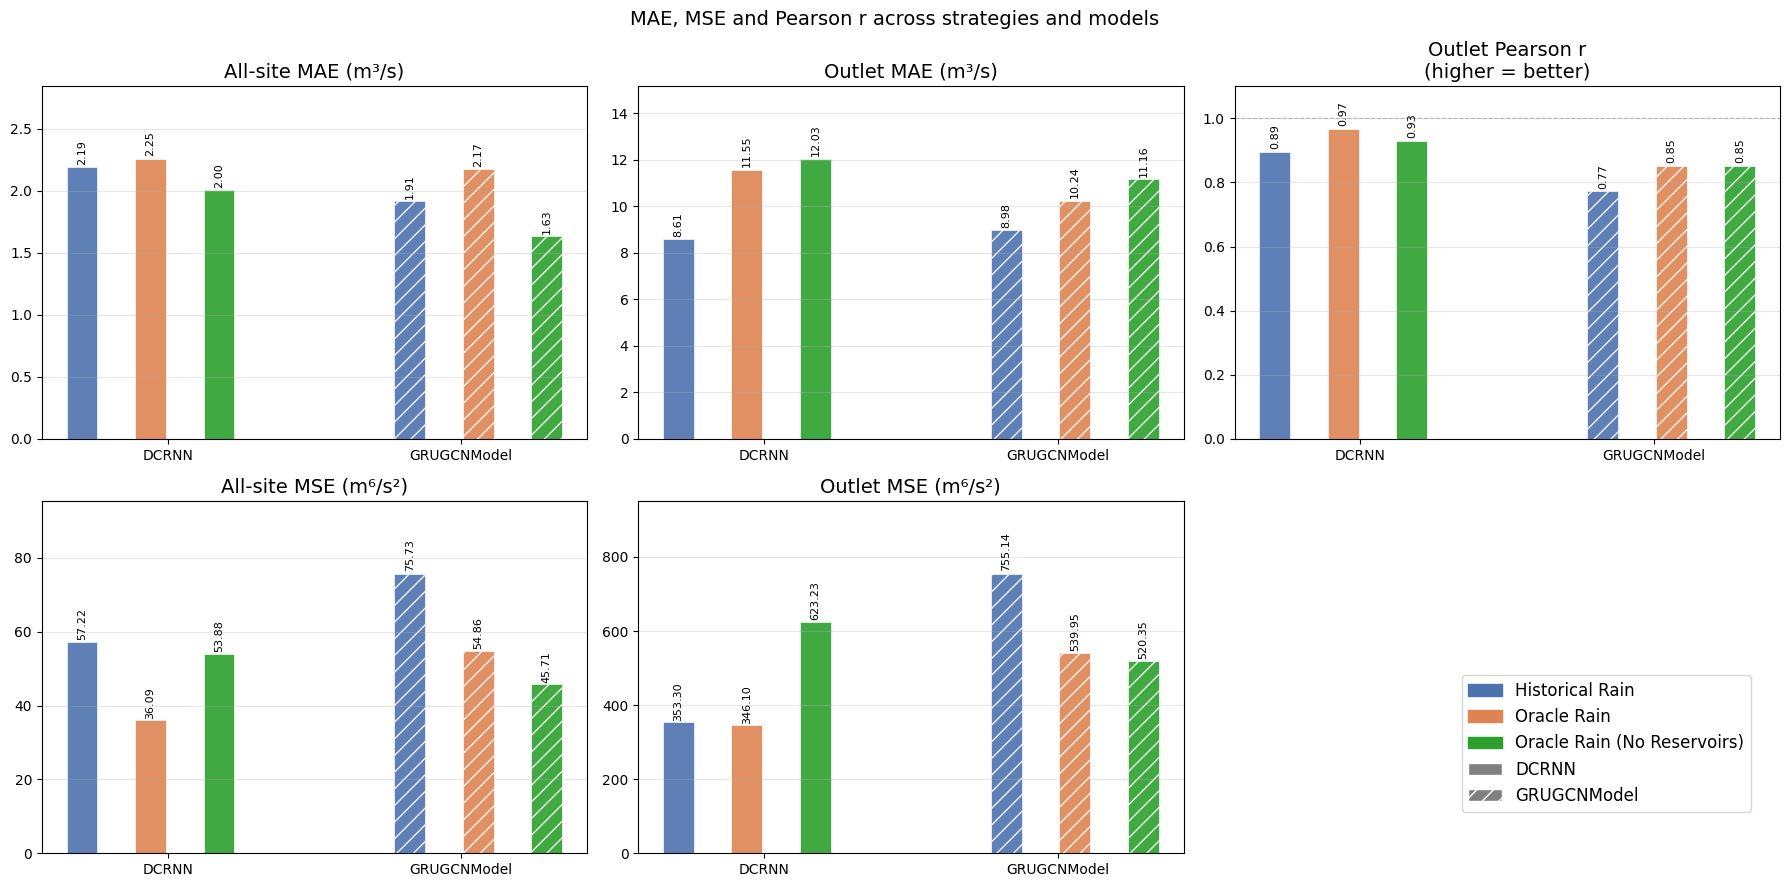

In [42]:
n_s, n_m = len(STRATEGIES), len(MODELS)
bar_w    = 0.7 / (n_s * n_m)
x        = np.arange(n_m)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('MAE, MSE and Pearson r across strategies and models', fontsize=14)

panel_cfg = [
    (axes[0, 0], 'All MAE',    'All-site MAE (m³/s)'),
    (axes[0, 1], 'Outlet MAE', 'Outlet MAE (m³/s)'),
    (axes[0, 2], 'Outlet r',   'Outlet Pearson r\n(higher = better)'),
    (axes[1, 0], 'All MSE',    'All-site MSE (m⁶/s²)'),
    (axes[1, 1], 'Outlet MSE', 'Outlet MSE (m⁶/s²)'),
    (axes[1, 2], None,         None),
]

strategy_patches = [mpatches.Patch(color=STRATEGY_COLORS[s],
                                   label=s.replace('\n', ' ')) for s in STRATEGIES]
model_patches    = [mpatches.Patch(facecolor='grey', hatch=MODEL_HATCHES[m],
                                   edgecolor='white', label=m) for m in MODELS]

for ax, col, title in panel_cfg:
    if col is None:
        ax.set_visible(False)
        continue
    for si, strategy in enumerate(STRATEGIES):
        for mi, model_name in enumerate(MODELS):
            key = (strategy.replace('\n', ' '), model_name)
            if key not in df.index:
                continue
            val    = df.loc[key, col]
            offset = (si * n_m + mi - (n_s * n_m - 1) / 2) * bar_w
            ax.bar(x[mi] + offset, val, width=bar_w * 0.9,
                   color=STRATEGY_COLORS[strategy],
                   hatch=MODEL_HATCHES[model_name],
                   edgecolor='white', linewidth=0.5, alpha=0.9)
            ax.text(x[mi] + offset, val * 1.01, f'{val:.2f}',
                    ha='center', va='bottom', fontsize=8, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=10)
    ax.set_title(title, fontsize=14)
    ax.tick_params(labelsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
    # r is bounded [0,1] so give it a fixed sensible axis
    if col == 'Outlet r':
        ax.set_ylim(0, 1.1)
        ax.axhline(1.0, color='grey', ls='--', lw=0.8, alpha=0.5)

fig.legend(handles=strategy_patches + model_patches,
           loc='lower right', ncol=1, fontsize=12,
           bbox_to_anchor=(0.98, 0.08))
plt.tight_layout()
plt.savefig('figures/strategy_mae_mse.png', dpi=300, bbox_inches='tight')
plt.show()


Outlet persistence diagnostic
Strategy                            Model           Model MAE  Persist MAE   % beat  corr(ŷ,y)   corr(ŷₜ,yₜ₋₁)
------------------------------------------------------------------------------------------------------------
Historical Rain                     DCRNN               8.610       11.453    24.8%      0.894           0.932
Historical Rain                     GRUGCNModel         8.984       11.453    21.6%      0.772           0.974

Oracle Rain                         DCRNN              11.555       11.453    -0.9%      0.967           0.708
Oracle Rain                         GRUGCNModel        10.241       11.453    10.6%      0.851           0.921

Oracle Rain (No Reservoirs)         DCRNN              12.032       11.453    -5.1%      0.928           0.685
Oracle Rain (No Reservoirs)         GRUGCNModel        11.163       11.453     2.5%      0.851           0.878



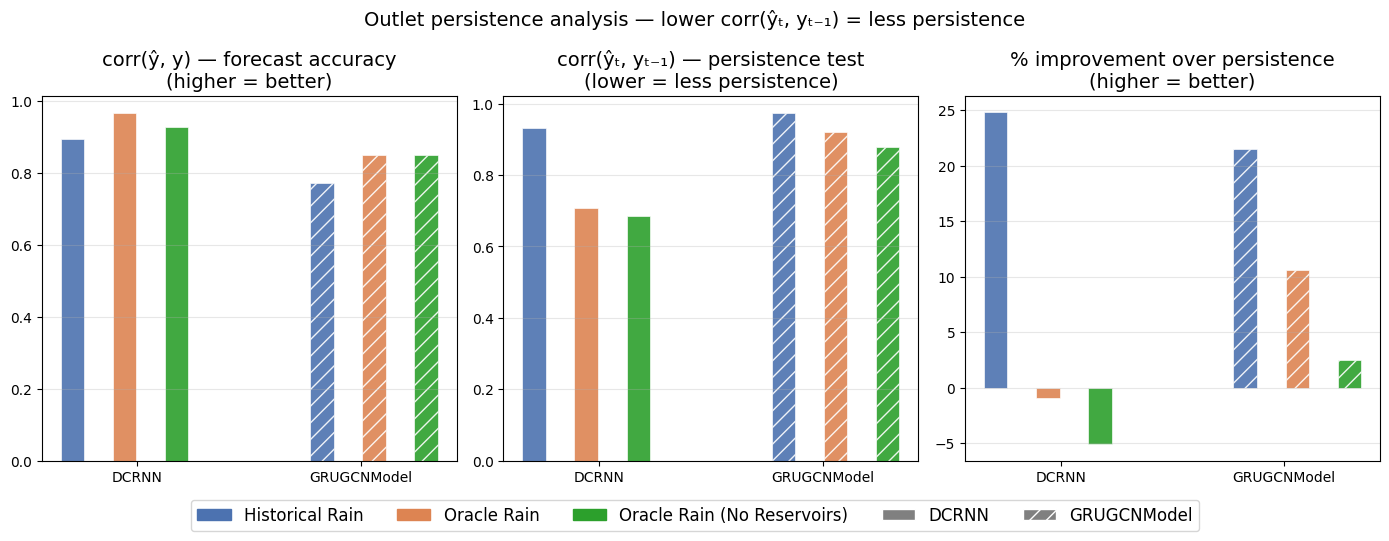

In [43]:
# ── Print table ──────────────────────────────────────────────────────────
print(f'Outlet persistence diagnostic')
print(f'{"Strategy":35s} {"Model":14s} {"Model MAE":>10s} {"Persist MAE":>12s} '
      f'{"% beat":>8s} {"corr(ŷ,y)":>10s} {"corr(ŷₜ,yₜ₋₁)":>15s}')
print('-' * 108)
persist_rows = []
for strategy in STRATEGIES:
    for model_name in MODELS:
        if model_name not in all_data.get(strategy, {}):
            continue
        fc = all_data[strategy][model_name]
        yt = fc['y_true'][:, OUTLET_NODE]
        yh = fc['y_hat'][:, OUTLET_NODE]
        p_mae  = float(np.abs(np.diff(yt)).mean())
        m_mae  = float(np.abs(yt - yh).mean())
        pct    = (p_mae - m_mae) / p_mae * 100
        c_same = float(np.corrcoef(yh, yt)[0, 1])
        c_lag1 = float(np.corrcoef(yh[1:], yt[:-1])[0, 1])
        print(f'{strategy.replace(chr(10)," "):35s} {model_name:14s} {m_mae:>10.3f} '
              f'{p_mae:>12.3f} {pct:>7.1f}% {c_same:>10.3f} {c_lag1:>15.3f}')
        persist_rows.append(dict(strategy=strategy, model=model_name,
                                 corr_same=c_same, corr_lag1=c_lag1, pct_beat=pct))
    print()

# ── Correlation bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Outlet persistence analysis — lower corr(ŷₜ, yₜ₋₁) = less persistence',
             fontsize=14)

panel_cfg2 = [
    (axes[0], 'corr_same',  'corr(ŷ, y) — forecast accuracy\n(higher = better)'),
    (axes[1], 'corr_lag1',  'corr(ŷₜ, yₜ₋₁) — persistence test\n(lower = less persistence)'),
    (axes[2], 'pct_beat',   '% improvement over persistence\n(higher = better)'),
]

for ax, field, title in panel_cfg2:
    for si, strategy in enumerate(STRATEGIES):
        for mi, model_name in enumerate(MODELS):
            row = next((r for r in persist_rows
                        if r['strategy'] == strategy and r['model'] == model_name), None)
            if row is None:
                continue
            val    = row[field]
            offset = (si * n_m + mi - (n_s * n_m - 1) / 2) * bar_w
            ax.bar(x[mi] + offset, val, width=bar_w * 0.9,
                   color=STRATEGY_COLORS[strategy],
                   hatch=MODEL_HATCHES[model_name],
                   edgecolor='white', linewidth=0.5, alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS)
    ax.set_title(title, fontsize=14)
    ax.grid(axis='y', alpha=0.3)

fig.legend(handles=strategy_patches + model_patches,
           loc='lower center', ncol=n_s + n_m, fontsize=12,
           bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('figures/strategy_persistence.png', dpi=300, bbox_inches='tight')
plt.show()


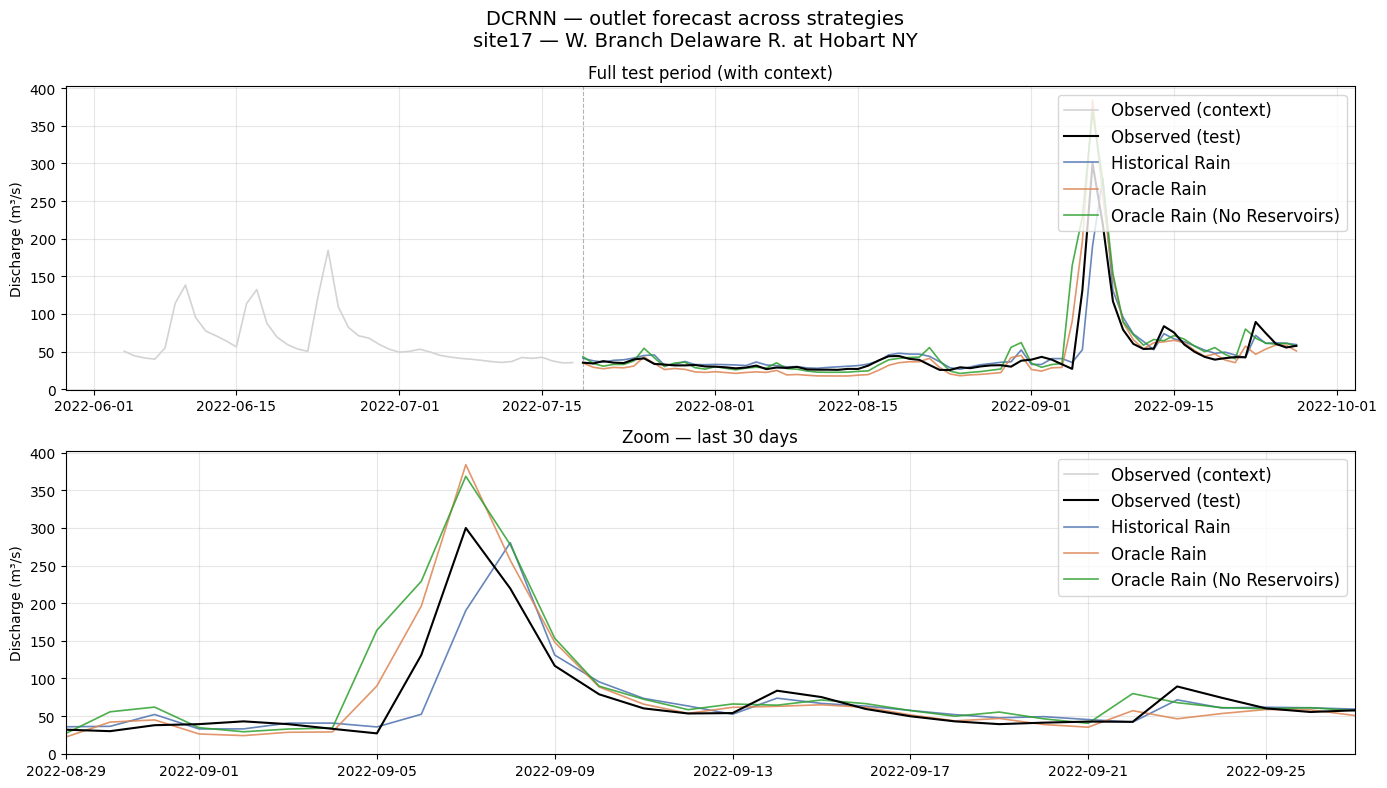

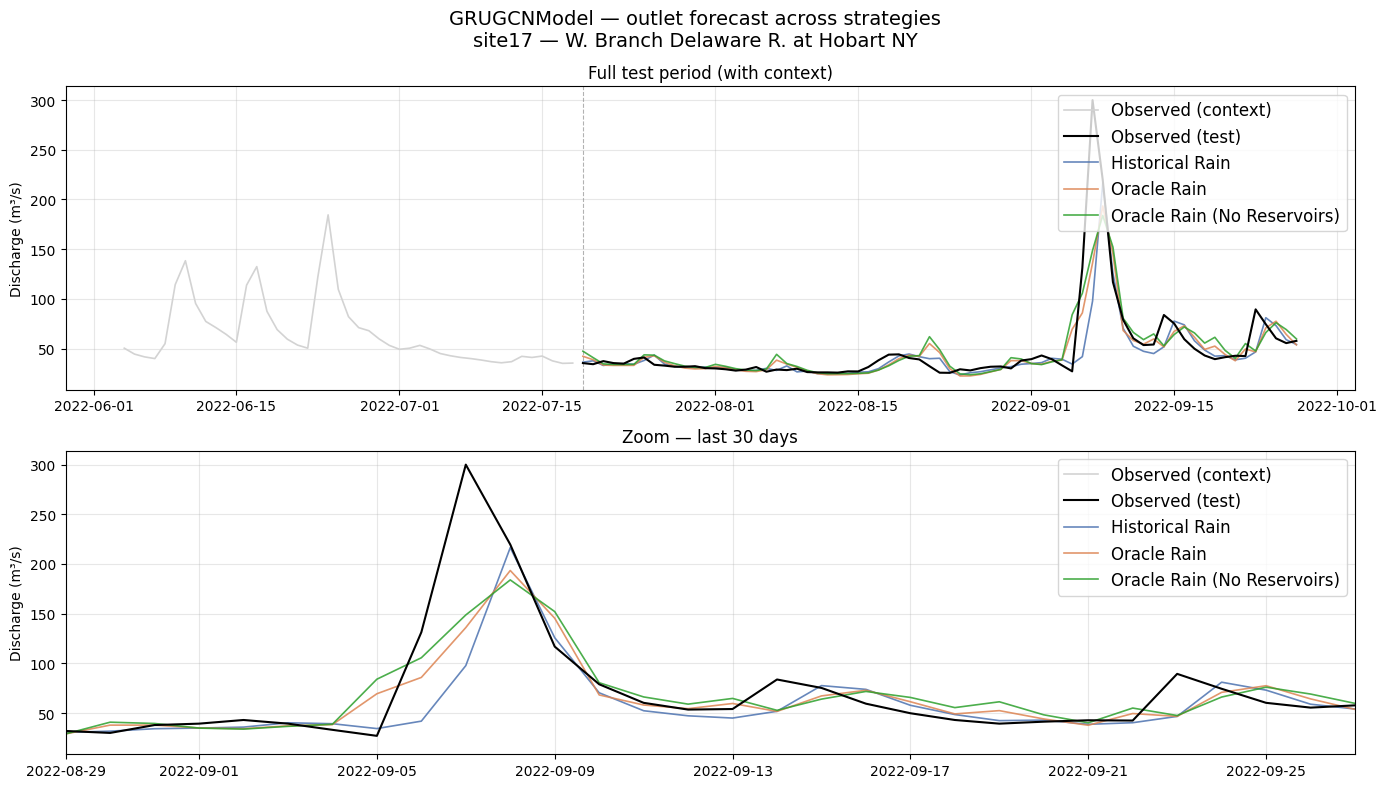

In [44]:
CONTEXT_DAYS = 45

for model_name in MODELS:
    ref_fc = next(
        all_data[s][model_name]
        for s in STRATEGIES if model_name in all_data.get(s, {})
    )
    dates      = ref_fc['dates']
    test_start = dates[0]
    context    = target.loc[
        test_start - pd.Timedelta(days=CONTEXT_DAYS) : test_start - pd.Timedelta(days=1),
        f'site{OUTLET_NODE}'
    ]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(f'{model_name} — outlet forecast across strategies\n{OUTLET_NAME}',
                 fontsize=14)

    for ax in axes:
        ax.plot(context.index, context.values, color='lightgrey', lw=1.2,
                label='Observed (context)')
        ax.plot(dates, ref_fc['y_true'][:, OUTLET_NODE], color='black',
                lw=1.5, label='Observed (test)', zorder=5)
        ax.axvline(test_start, color='grey', ls='--', lw=0.8, alpha=0.6)
        for strategy in STRATEGIES:
            if model_name not in all_data.get(strategy, {}):
                continue
            fc = all_data[strategy][model_name]
            ax.plot(fc['dates'], fc['y_hat'][:, OUTLET_NODE],
                    color=STRATEGY_COLORS[strategy], lw=1.2, alpha=0.85,
                    label=strategy.replace('\n', ' '))
        ax.set_ylabel('Discharge (m³/s)')
        ax.legend(fontsize=12, loc='upper right')
        ax.grid(alpha=0.3)

    axes[0].set_title('Full test period (with context)')
    axes[1].set_xlim(dates[-30], dates[-1])
    axes[1].set_title('Zoom — last 30 days')
    plt.tight_layout()
    plt.savefig(f'figures/strategy_outlet_{model_name}.png', dpi=300)
    plt.show()


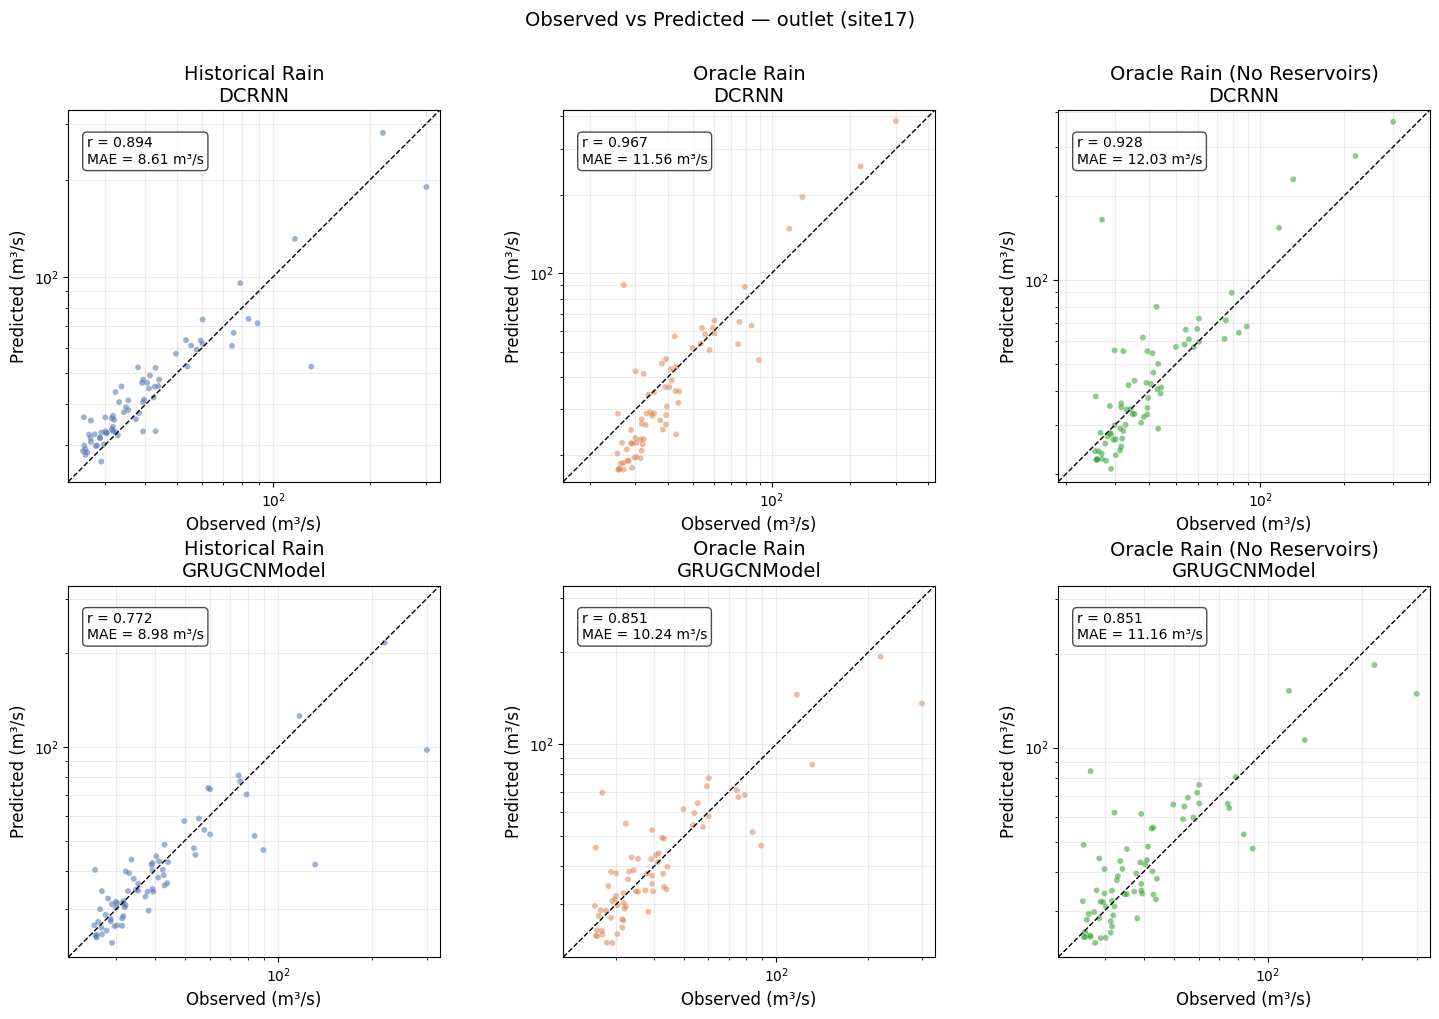

In [45]:
n_s, n_m = len(STRATEGIES), len(MODELS)
fig, axes = plt.subplots(n_m, n_s, figsize=(5 * n_s, 5 * n_m))
fig.suptitle(f'Observed vs Predicted — outlet (site{OUTLET_NODE})', fontsize=14, y=1.01)

for mi, model_name in enumerate(MODELS):
    for si, strategy in enumerate(STRATEGIES):
        ax = axes[mi, si]
        if model_name not in all_data.get(strategy, {}):
            ax.set_visible(False)
            continue
        fc  = all_data[strategy][model_name]
        yt  = fc['y_true'][:, OUTLET_NODE].clip(1e-2)
        yh  = fc['y_hat'][:, OUTLET_NODE].clip(1e-2)
        mae = float(np.abs(fc['y_true'][:, OUTLET_NODE] - fc['y_hat'][:, OUTLET_NODE]).mean())
        r   = float(np.corrcoef(yt, yh)[0, 1])
        ax.scatter(yt, yh, s=18, alpha=0.55,
                   color=STRATEGY_COLORS[strategy], edgecolors='none')
        lim = [min(yt.min(), yh.min()) * 0.9, max(yt.max(), yh.max()) * 1.1]
        ax.plot(lim, lim, color='black', lw=1.0, ls='--', zorder=3)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_aspect('equal')
        ax.set_title(f'{strategy.replace(chr(10)," ")}\n{model_name}', fontsize=14)
        ax.set_xlabel('Observed (m³/s)', fontsize=12)
        ax.set_ylabel('Predicted (m³/s)', fontsize=12)
        ax.tick_params(labelsize=10)
        ax.grid(alpha=0.25, which='both')
        ax.text(0.05, 0.93, f'r = {r:.3f}\nMAE = {mae:.2f} m³/s',
                transform=ax.transAxes, fontsize=10, va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
plt.savefig('figures/outlet_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
